<a href="https://colab.research.google.com/github/sidharth463/24BSE1211-PDE-MicroProject-Group-14-/blob/main/The_Micro_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Micro-Project: 1D Image Blurring Simulation (The Heat Equation)

## 1. Aim
To simulate and analyze the isotropic diffusion of pixel intensity along a 1D digital image scan line using a Fourier series approximation of the 1D heat equation.

## 2. Objective
* To implement a numerical model in Python that visualizes signal degradation over time.
* To evaluate how sharp image edges transform into smooth gradients through mathematical low-pass filtering.
* To study the behavior of spatial frequency components under exponential time-decay.

## 3. Algorithm / Computational Steps
1. **Initialize Parameters:** Set the scan line length ($L = 1.0$), diffusion coefficient ($\alpha = 0.02$), and the number of Fourier terms ($N = 150$).
2. **Define Spatial Domain:** Generate a continuous set of spatial points $x$ along the scan line using `numpy.linspace`.
3. **Compute Fourier Series Expansion:**
   * Calculate the base intensity term ($a_0 / 2 = 0.5$).
   * Loop through spatial frequencies $n = 1$ to $N$, calculating the Fourier coefficients $a_n = -\frac{2}{n\pi}\sin\left(\frac{n\pi}{2}\right)$.
   * Compute spatial cosine components and temporal exponential decay factors $e^{-\alpha(n\pi/L)^2 t}$.
4. **Evaluate Time Steps:** Calculate signal intensity $I(x,t)$ across three discrete time milestones:
   * $t = 0.0$ (Initial sharp step function)
   * $t = 0.1$ (Early stage diffusion / slight blur)
   * $t = 0.5$ (Advanced diffusion / heavy blur)
5. **Plot and Visualize:** Use `matplotlib` to render the intensity profiles and contrast the degradation curves against spatial positions.

## 4. Description & Physical Interpretation
* **Behavior at $t = 0$:** Represents an unblurred edge. The minor oscillations near the boundary are a manifestation of the *Gibbs phenomenon*, which occurs when approximating a discontinuous step function with continuous trigonometric series.
* **Behavior at $t = 0.1$ and $0.5$:** As time increases, high-frequency spatial terms decay exponentially faster due to the quadratic term in the exponent. This confirms that the heat equation acts mathematically as a **low-pass filter**, smoothing rapid intensity variations while preserving lower-frequency trends.
*

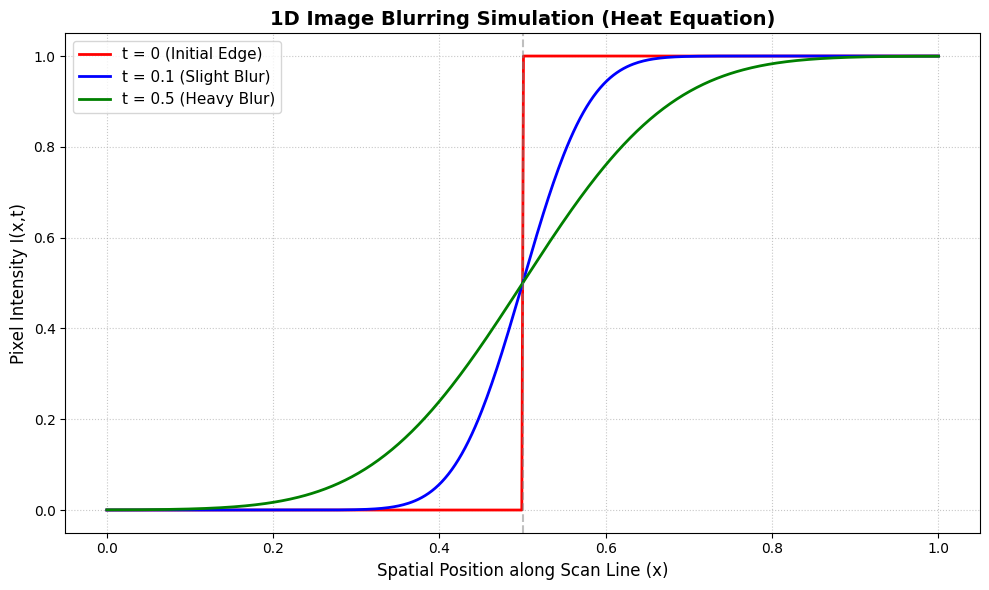

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fourier_series_blur(x, t, L=1.0, alpha=0.01, terms=100):
    """
    Computes the 1D heat equation solution for a step function using Fourier series.
    """
    # a_0 / 2 term
    intensity = np.full_like(x, 0.5)

    # Summing the Fourier terms
    for n in range(1, terms + 1):
        # Calculate coefficient an
        an = -(2 / (n * np.pi)) * np.sin(n * np.pi / 2)

        # Calculate spatial and temporal components
        spatial = np.cos(n * np.pi * x / L)
        temporal = np.exp(-alpha * (n * np.pi / L)**2 * t)

        # Add to total intensity
        intensity += an * spatial * temporal

    return intensity

# --- Simulation Parameters ---
L = 1.0          # Length of the scan line
alpha = 0.02     # Diffusion coefficient (controls speed of blur)
x_vals = np.linspace(0, L, 500) # Spatial domain

# Time steps defined in the assignment
time_steps = [0.0, 0.1, 0.5]
colors = ['red', 'blue', 'green']
labels = ['t = 0 (Initial Edge)', 't = 0.1 (Slight Blur)', 't = 0.5 (Heavy Blur)']

# --- Plotting ---
plt.figure(figsize=(10, 6))

for t, color, label in zip(time_steps, colors, labels):
    if t == 0.0:
        y_vals = np.where(x_vals >= L/2, 1.0, 0.0)
    else:
        y_vals = fourier_series_blur(x_vals, t, L=L, alpha=alpha, terms=150)

    plt.plot(x_vals, y_vals, color=color, label=label, linewidth=2)

# Formatting the visual plot
plt.title("1D Image Blurring Simulation (Heat Equation)", fontsize=14, fontweight='bold')
plt.xlabel("Spatial Position along Scan Line (x)", fontsize=12)
plt.ylabel("Pixel Intensity I(x,t)", fontsize=12)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Inline generation of the result
plt.show()